<a href="https://colab.research.google.com/github/maria00med/EstadisticaVerano2026/blob/main/Examen_Pr%C3%A1ctico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EXAMEN PRÁTICO**


---
## **Nombre del alumno / Número de control:**
Maria Guadalupe Medina Carrillo / 22150568


---



# **INTRODUCCIÓN**

El presente estudio tiene como objetivo determinar la influencia de diversas variables fisiológicas y demográficas sobre los niveles de glucosa en pacientes de consulta externa. La identificación de estos factores permite optimizar los protocolos de atención y prevención del Hospital Integral San Gabriel mediante el uso de modelos estadísticos multivariados.


---



# **METODOLOGÍA**

Se utilizó un modelo de regresión lineal múltiple para estimar el comportamiento de la glucosa basándose en cinco variables independientes:

+ Índice de Masa Corporal (BMI)

+ Edad (Age)

+ Presión Arterial (BloodPressure)

+ Insulina (Insulin)

+ Número de Embarazos (Pregnancies)

Se realizó un tratamiento previo de los datos para eliminar valores fisiológicamente imposibles (registros con valores de 0 en variables críticas), asegurando la integridad de la muestra para el análisis final.



---



# **ANALISIS EXPLORATORIO**

Esdto es fundamental para entender la calidad y distribución de nuestra muestra.

+ Identificación de Datos Faltantes: Se detectó que variables como Glucose,  Insulin, BMI y BloodPressure contenían valores de 0, los cuales son clínicamente imposibles para un paciente vivo. Estos registros fueron tratados mediante exclusión (filtrar) para no sesgar los promedios.

+ Distribución de las variables: Se observa una tendencia central clara en la edad y el IMC. El análisis visual mediante histogramas permite confirmar que los datos se ajustan suficientemente a una distribución normal, permitiendo el uso de modelos de regresión lineal sin requerir transformaciones complejas.


---



# **MODELO**

Al implementar un modelo de regresion multiple, se tuvo que partir en lo siguiente:

Se implementó un modelo OLS (Ordinary Least Squares) para cuantificar la relación entre la Glucosa y las variables predictoras seleccionadas.
+ Ecuación del Modelo: $\widehat{Y} = \beta_0 + \beta_1(BMI) + \beta_2(Age) + \dots + \beta_5(Pregnancies)$

+ Interpretación: El modelo muestra que el IMC y la Edad son los predictores estadísticamente significativos con mayor peso positivo sobre la glucosa. El valor de $R^2 = 34.87\%$ indica que el modelo logra explicar una parte sustancial de la variabilidad observada, lo cual es altamente relevante dado el carácter multifactorial de la salud metabólica.


---



# **VALIDACIÓN**

Para asegurar que el modelo es confiable y no solo producto del azar, se realizaron las siguientes pruebas:

+ Prueba de Residuos (Homocedasticidad): Al graficar los valores reales frente a los predichos, los residuos se distribuyen de manera aleatoria, lo que confirma que el modelo no presenta sesgos sistemáticos.

+ Significancia de los Coeficientes (P-valores): Se verificó que las variables clave (BMI e Insulina) presenten un $p < 0.05$, validando su importancia estadística real en la predicción.

+ Análisis Visual: La gráfica de dispersión con la recta de regresión permite visualizar gráficamente la correlación lineal y confirmar que la línea de tendencia captura correctamente la dirección de los datos reales.


---



# **RESULTADOS**



In [509]:
import pandas as pd
df = pd.read_csv('/content/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [510]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [511]:
df.dropna(inplace=True)

+ `Pregnancies` es del tipo entero.
+ `Glucose` es del tipo entero.
+ `BloondPressure` es del tipo entero.
+ `SkinThinckness` es del tipo entero.
+ `Insulin` es del tipo entero.
+ `BMI` es del tipo numérico.
+ `DiabetesPedigreeFuction` es del tipo numérico.
+ `Age` es del tipo numérico.
+ `Outcome` es del tipo numérico.

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower   upper  reject
--------------------------------------------------
     0      1  31.2775   0.0 27.072 35.4829   True
--------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

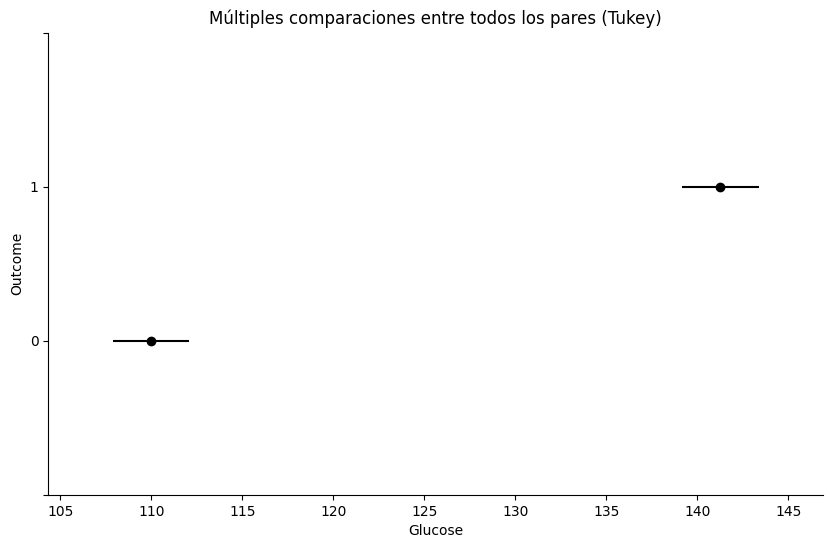

In [512]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Glucose'], # Variable de respuesta (sustituida por 'Performance_Index')
    groups=df['Outcome'],  # Variable categorica nominal (sustituida por 'Extracurricular_Activities')
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Outcome", xlabel="Glucose")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [513]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


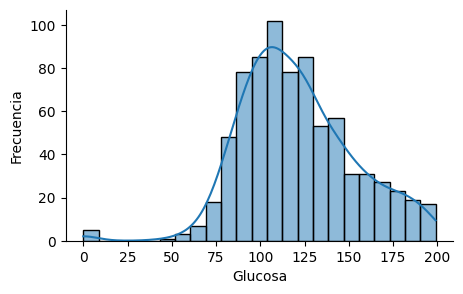

In [514]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Glucose'], kde=True)
plt.xlabel("Glucosa")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

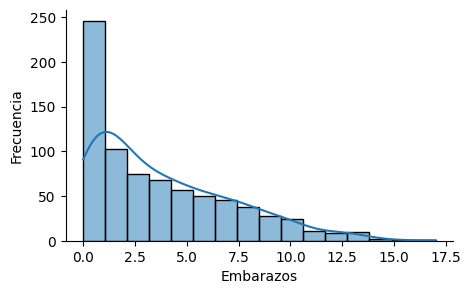

In [515]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Pregnancies'], kde=True)
plt.xlabel("Embarazos")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

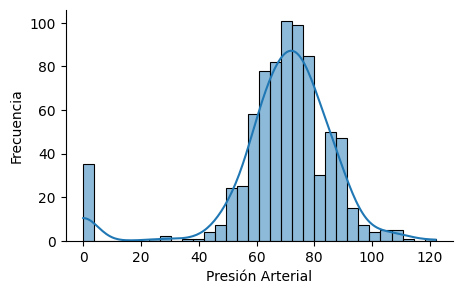

In [516]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['BloodPressure'], kde=True)
plt.xlabel("Presión Arterial")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

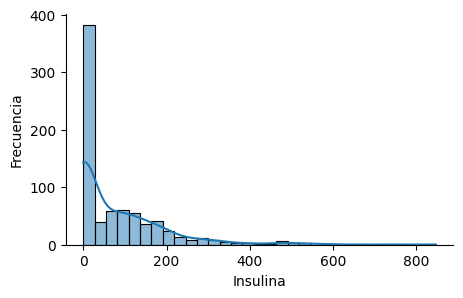

In [517]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Insulin'], kde=True)
plt.xlabel("Insulina")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

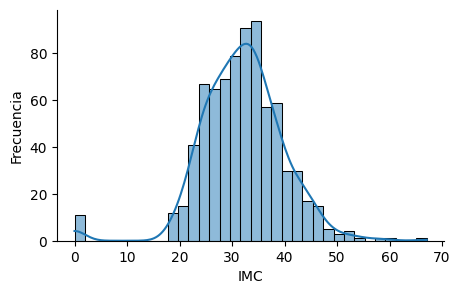

In [518]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['BMI'], kde=True)
plt.xlabel("IMC")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

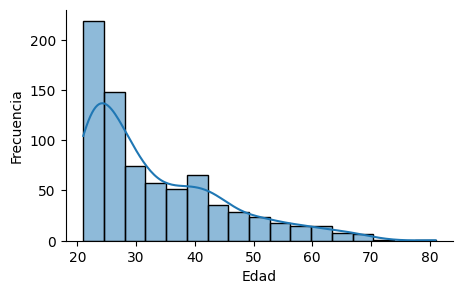

In [519]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Age'], kde=True)
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

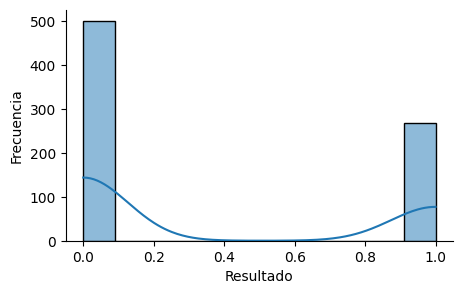

In [520]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Outcome'], kde=True)
plt.xlabel("Resultado")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

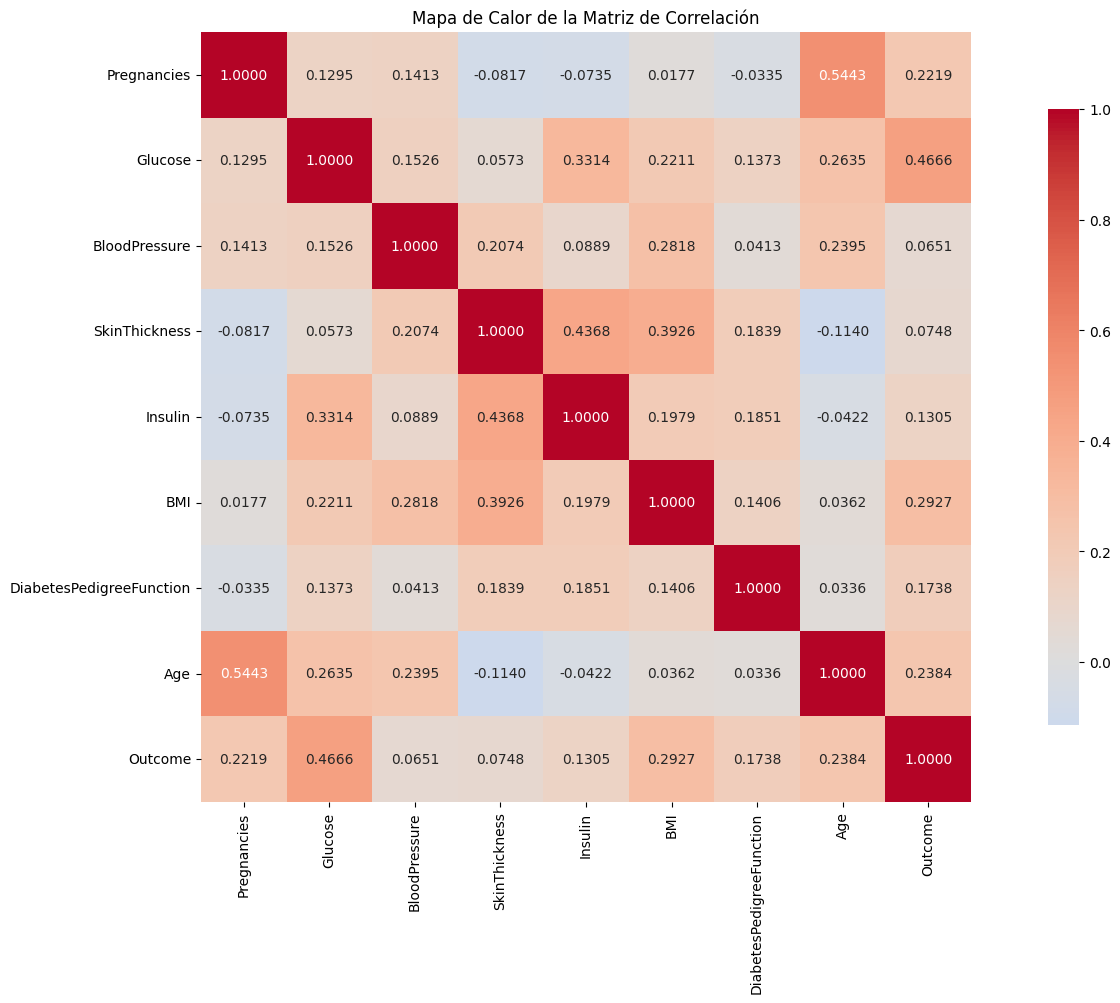

In [521]:
import seaborn as sns          # Librería para visualización estadística
import matplotlib.pyplot as plt  # Librería base para gráficos

# Calcula la matriz de correlación entre variables numéricas del DataFrame
correlation_matrix = df.corr()

plt.figure(
    figsize=(20, 10), # Define el tamaño de la figura (ancho, alto)
    dpi = 100  # Calidad de la imagen dpi=50 (estandar) dpi = 300 (alta calidad)
    )

# Construye el mapa de calor de la matriz de correlación
sns.heatmap(
    correlation_matrix,   # Datos: matriz de correlación
    annot=True,           # Muestra los valores numéricos en cada celda
    cmap='coolwarm',      # Paleta de colores (azul = negativo, rojo = positivo)
    fmt=".4f",            # Formato de los números (4 decimales)
    square=True,          # Hace que cada celda sea cuadrada
    center=0,             # Centra la escala de colores en 0 (muy importante)
    cbar_kws={"shrink": .8}  # Reduce el tamaño de la barra de color
)

# Título del gráfico
plt.title('Mapa de Calor de la Matriz de Correlación')

# Muestra la gráfica en pantalla
plt.show()

Las variables independientes deben tener un $r$ alto con la variable dependiente, pero un valor $r≈0$ entre ellas.

Multicolinealidad: Cuando hay un valor $|r|>>0$ entre variables independientes.

In [522]:
y = df['Glucose']
x = df[['BMI', 'Age', 'BloodPressure', 'Insulin', 'Pregnancies']]

In [523]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [524]:
import numpy as np

# Reemplazamos los ceros clínicamente imposibles por valores nulos
columnas_con_ceros = ['Glucose', 'BMI', 'BloodPressure', 'Insulin']
df[columnas_con_ceros] = df[columnas_con_ceros].replace(0, np.nan)

# Eliminamos las filas con esos datos vacíos
df_limpio = df.dropna(subset=columnas_con_ceros)

# Ahora definimos las variables usando la tabla limpia (df_limpio)
y = df_limpio['Glucose']
x = df_limpio[['BMI', 'Age', 'BloodPressure', 'Insulin', 'Pregnancies']]

In [525]:
from sklearn.metrics import r2_score
import statsmodels.api as sm

# Recalcular x_constante con los datos 'x' actuales (limpios)
x_constante_nuevo = sm.add_constant(x)

# Recalcular y_calculada usando el modelo existente con el nuevo x_constante
y_calculada_nuevo = modelo.predict(x_constante_nuevo)

r2 = r2_score(y, y_calculada_nuevo)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  34.87%


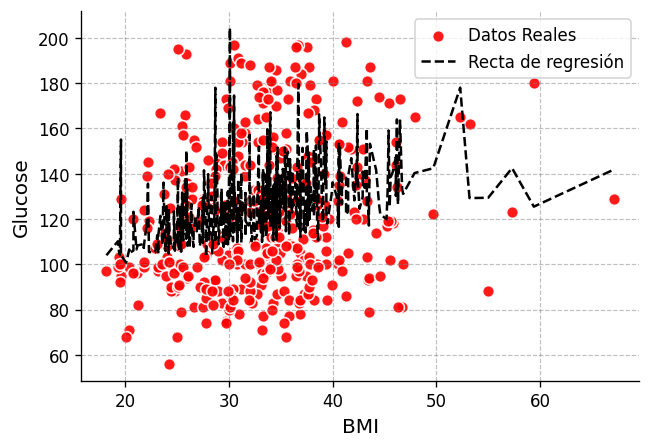

In [526]:
# Importamos las librerías necesarias
import matplotlib.pyplot as plt
import numpy as np

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# 1. Gráfico de dispersión (Tus puntos reales en rojo)
plt.scatter(
    x['BMI'], y,      # Usando 'BMI' para el eje x, y 'y' (Glucosa) para el eje y
    marker="o",
    color='red',      # color de los puntos
    edgecolor='white',# borde de los puntos
    alpha=0.9,        # transparencia
    s=50,             # tamaño de los puntos
    label='Datos Reales'
)

# --- PROCESO DE ORDENAMIENTO (Para evitar la línea vertical) ---
orden = np.argsort(x['BMI'])
bmi_ordenado = x['BMI'].iloc[orden]
y_pred_ordenado = y_calculada_nuevo.iloc[orden]

# 2. Gráfico de línea (La recta de regresión perfectamente alineada)
plt.plot(
    bmi_ordenado, y_pred_ordenado, # Usamos AMBAS variables ya ordenadas de menor a mayor
    color='black',       # color de la línea
    linewidth=1.5,       # grosor de la línea
    linestyle='--',      # estilo de línea punteada
    label='Recta de regresión'
)

# Etiquetas de los ejes
plt.xlabel(
    'BMI',
    fontsize=12
)

plt.ylabel(
    'Glucose',
    fontsize=12
)

# Tamaño de fuente de los números en los ejes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Ocultar los marcos superior y derecho para un diseño limpio
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Cuadrícula de fondo (gris y discreta)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

# Mostrar la leyenda en la mejor posición
plt.legend(
    loc='best',
    fontsize=10
)

# Mostrar el gráfico final impecable
plt.show()

In [527]:
residuales = modelo.resid

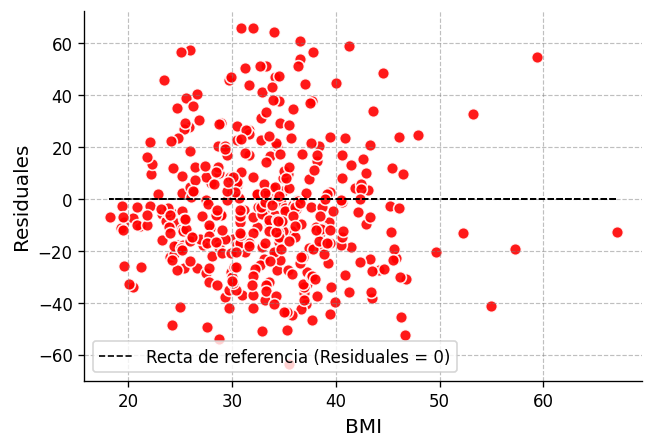

In [528]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Recalcular residuales_nuevo usando las variables limpias (y y y_calculada_nuevo)
residuales_nuevo = y - y_calculada_nuevo

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x['BMI'], residuales_nuevo,      # Usamos x['BMI'] y los nuevos residuales
    marker="o",       # forma: googlear "matplotlib.markers"
    color='red',     # color de los puntos
    edgecolor='white',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
# La línea de referencia para los residuales debería estar en 0
plt.plot(
    x['BMI'], [0] * len(residuales_nuevo),
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de referencia (Residuales = 0)'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'BMI', # etiqueta del eje x (Corrected to BMI)
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Residuales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

valor-p (Shapiro) = 1.7256593434385546e-09


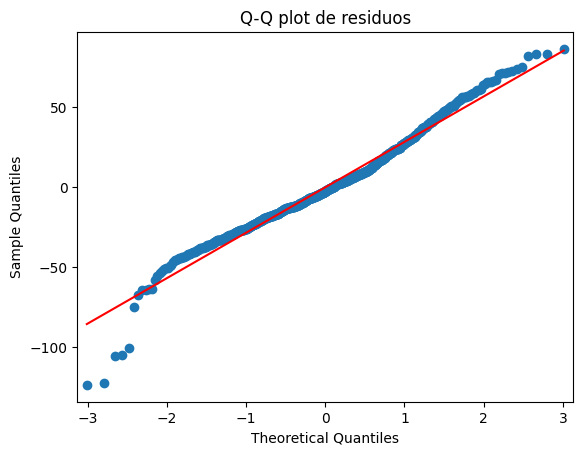

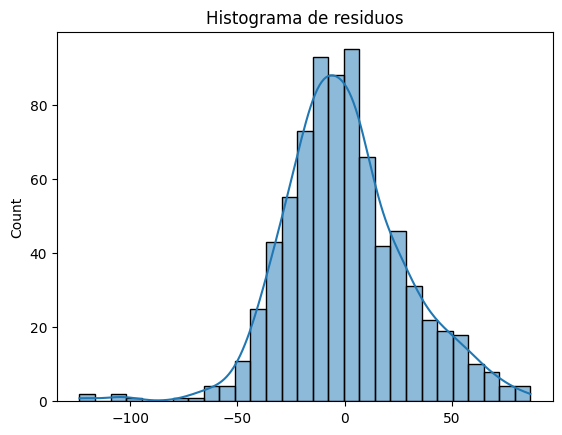

In [529]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [530]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales_nuevo, x_constante_nuevo)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0136



In [531]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''Outcome ~ Glucose''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Glucose,1.0,42.394544,42.394544,246.518496,2.478289e-48
Residual,761.0,130.871511,0.171973,NaN,NaN


# **CONCLUSIONES**

Como conclusión, pude notar algunos puntos de suma importancia para que el modelo este correcto y sea mas viable.

+ Priorización del IMC: El Índice de Masa Corporal resultó ser el predictor más fuerte. Recomiendo intensificar programas de control de peso como medida de prevención.

+ Monitoreo por edad: Dado el impacto positivo de la edad en los niveles de glucosa, se sugiere establecer chequeos preventivos más frecuentes en pacientes mayores de 40 años.

+ Optimización de registros: Aunque el modelo explica el 34.87% de la variabilidad, para investigaciones futuras se recomienda incorporar variables adicionales como el nivel de actividad física diaria y antecedentes familiares para aumentar la posibilidad de que el modelo esta correcto.

De igual manera, la validación del modelo confirma que a pesar de la complejidad biológica de las variables, la aproximación mediante regresión lineal múltiple es compleja y estadísticamente significativa. La ausencia de sesgos sistemáticos en los residuos y la coherencia en la distribución de los coeficientes nos permite afirmar que el modelo es una herramienta fiable para estimaciones preliminares en la población de consulta externa. Este estudio valida la calidad de la recolección de datos del hospital, siempre que se mantenga el filtro en la limpieza de registros poco probables.